# 03 – Feature Engineering

Goal: Build the feature matrix for XGBoost training.

Features constructed:
1. **Macro lag features** – lags 1–6 for all four macro indicators (non-stationary series as first differences)
2. **Calendar features** – month, quarter, year, is_q4
3. **Autoregressive features** – revenue at lag 1, 2, 3 months
4. **Rolling window features** – 3M and 6M rolling mean and std of revenue

Output: `data/processed/feature_matrix.csv` — one row per product × month, with a `product` column for flexible filtering.

**Note:** XGBoost training targets Compressors/US (B3). Accessories is included in the matrix for completeness and can be filtered out at training time. Lag selection is intentionally left to XGBoost feature importance and SHAP — CCF results from 02 serve as a plausibility check only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')

DATA_RAW       = '../data/raw/'
DATA_PROCESSED = '../data/processed/'

# Non-stationary series (from ADF results in 02) — will be first-differenced
NON_STATIONARY = ['de_production_index', 'us_durable_goods_orders_musd', 'us_production_index']
STATIONARY     = ['de_orders_index']
MACRO_COLS     = STATIONARY + NON_STATIONARY

LAG_RANGE = range(1, 7)  # lags 1–6

---
## 1. Load Revenue Data

In [2]:
# Load Net Value per product
net_value = pd.read_excel(DATA_RAW + 'DGE_Revenue_Planning_Actuals_Net_Value_US.xlsx', sheet_name=0)
net_value = net_value.rename(columns={'Unnamed: 4': 'net_value_usd'})
net_value['date'] = pd.to_datetime(net_value['Date'].astype(str), format='%Y%m')
net_value = net_value[['date', 'Product', 'net_value_usd']].dropna().sort_values('date').reset_index(drop=True)

print('Revenue shape:', net_value.shape)
print('Products:', net_value['Product'].unique())
print('Date range:', net_value['date'].min(), '–', net_value['date'].max())
net_value.head()

Revenue shape: (78, 3)
Products: <StringArray>
['Accessories', 'Compressors']
Length: 2, dtype: str
Date range: 2022-10-01 00:00:00 – 2025-12-01 00:00:00


,date,Product,net_value_usd
0,2022-10-01,Accessories,1868.72
1,2022-10-01,Compressors,2353253.00
2,2022-11-01,Accessories,-556.05
3,2022-11-01,Compressors,2250209.00
4,2022-12-01,Accessories,4277.21


---
## 2. Load & Prepare Macro Features

In [3]:
# Load processed macro data from 02_macro_data.ipynb
macro = pd.read_csv(DATA_PROCESSED + 'macro_features.csv', parse_dates=['date'])

print('Macro shape:', macro.shape)
print('Date range:', macro['date'].min(), '–', macro['date'].max())
macro.head()

Macro shape: (96, 5)
Date range: 2018-01-01 00:00:00 – 2025-12-01 00:00:00


,date,de_orders_index,de_production_index,us_durable_goods_orders_musd,us_production_index
0,2018-01-01,97.7,107.2,228219,101.4625
1,2018-02-01,95.8,104.9,236950,101.7085
2,2018-03-01,97.9,106.4,244343,102.2067
3,2018-04-01,95.4,106.2,243872,103.3329
4,2018-05-01,97.5,108.0,243168,102.4024


In [4]:
# Apply first differences to non-stationary series
# The differenced columns are named with a '_diff' suffix to distinguish from levels
macro_prep = macro.copy()

for col in NON_STATIONARY:
    macro_prep[f'{col}_diff'] = macro_prep[col].diff()

# Drop original non-stationary level columns — use diff versions for lag features
macro_prep = macro_prep.drop(columns=NON_STATIONARY)

print('Prepared macro columns:', list(macro_prep.columns))
macro_prep.head()

Prepared macro columns: ['date', 'de_orders_index', 'de_production_index_diff', 'us_durable_goods_orders_musd_diff', 'us_production_index_diff']


,date,de_orders_index,de_production_index_diff,us_durable_goods_orders_musd_diff,us_production_index_diff
0,2018-01-01,97.7,NaN,NaN,NaN
1,2018-02-01,95.8,-2.3,8731.0,0.2460
2,2018-03-01,97.9,1.5,7393.0,0.4982
3,2018-04-01,95.4,-0.2,-471.0,1.1262
4,2018-05-01,97.5,1.8,-704.0,-0.9305


---
## 3. Merge Revenue + Macro

In [5]:
# Merge on date — left join keeps all revenue months
# Revenue starts 2022-10, macro starts 2018-01 → all revenue dates will find a macro match
df = net_value.merge(macro_prep, on='date', how='left').sort_values(['Product', 'date']).reset_index(drop=True)

print('Merged shape:', df.shape)
print('Missing values after merge:')
print(df.isnull().sum())
df.head()

Merged shape: (78, 7)
Missing values after merge:
date                                 0
Product                              0
net_value_usd                        0
de_orders_index                      0
de_production_index_diff             0
us_durable_goods_orders_musd_diff    0
us_production_index_diff             0
dtype: int64


,date,Product,net_value_usd,de_orders_index,de_production_index_diff,us_durable_goods_orders_musd_diff,us_production_index_diff
0,2022-10-01,Accessories,1868.72,90.6,-0.8,4641.0,-0.0389
1,2022-11-01,Accessories,-556.05,89.2,0.4,-7976.0,-0.2977
2,2022-12-01,Accessories,4277.21,93.0,-2.7,14263.0,-1.1888
3,2023-01-01,Accessories,-1236.25,86.9,2.2,-4484.0,0.7386
4,2023-02-01,Accessories,-246.35,91.7,2.0,-8181.0,0.1366


---
## 4. Macro Lag Features (Lags 1–6)

Lag features are created per product group to avoid cross-product data leakage.
Each macro column gets 6 lagged versions: `{col}_lag_1` … `{col}_lag_6`.

In [6]:
# Macro columns available after differencing
macro_feature_cols = [c for c in df.columns if c not in ['date', 'Product', 'net_value_usd']]
print('Macro feature columns:', macro_feature_cols)

# Create lag features per product group
lag_frames = []
for product, group in df.groupby('Product'):
    group = group.sort_values('date').copy()
    for col in macro_feature_cols:
        for lag in LAG_RANGE:
            group[f'{col}_lag_{lag}'] = group[col].shift(lag)
    lag_frames.append(group)

df = pd.concat(lag_frames).sort_values(['Product', 'date']).reset_index(drop=True)

# Drop the unlagged macro columns — only lags are used as features
df = df.drop(columns=macro_feature_cols)

print('\nShape after macro lag features:', df.shape)
lag_cols = [c for c in df.columns if '_lag_' in c]
print(f'Lag feature columns created: {len(lag_cols)}')

Macro feature columns: ['de_orders_index', 'de_production_index_diff', 'us_durable_goods_orders_musd_diff', 'us_production_index_diff']

Shape after macro lag features: (78, 27)
Lag feature columns created: 24


---
## 5. Calendar Features

In [7]:
df['month']   = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['year']    = df['date'].dt.year
df['is_q4']   = (df['quarter'] == 4).astype(int)  # B2B year-end effect

print('Calendar features added: month, quarter, year, is_q4')
df[['date', 'Product', 'month', 'quarter', 'year', 'is_q4']].head(8)

Calendar features added: month, quarter, year, is_q4


,date,Product,month,quarter,year,is_q4
0,2022-10-01,Accessories,10,4,2022,1
1,2022-11-01,Accessories,11,4,2022,1
2,2022-12-01,Accessories,12,4,2022,1
3,2023-01-01,Accessories,1,1,2023,0
4,2023-02-01,Accessories,2,1,2023,0
5,2023-03-01,Accessories,3,1,2023,0
6,2023-04-01,Accessories,4,2,2023,0
7,2023-05-01,Accessories,5,2,2023,0


---
## 6. Autoregressive Features (Revenue Lag 1–3)

Computed per product group to avoid leakage between products.

In [8]:
ar_frames = []
for product, group in df.groupby('Product'):
    group = group.sort_values('date').copy()
    for lag in [1, 2, 3]:
        group[f'revenue_lag_{lag}'] = group['net_value_usd'].shift(lag)
    ar_frames.append(group)

df = pd.concat(ar_frames).sort_values(['Product', 'date']).reset_index(drop=True)

print('AR features added: revenue_lag_1, revenue_lag_2, revenue_lag_3')
df[['date', 'Product', 'net_value_usd', 'revenue_lag_1', 'revenue_lag_2', 'revenue_lag_3']].head(8)

AR features added: revenue_lag_1, revenue_lag_2, revenue_lag_3


,date,Product,net_value_usd,revenue_lag_1,revenue_lag_2,revenue_lag_3
0,2022-10-01,Accessories,1868.72,NaN,NaN,NaN
1,2022-11-01,Accessories,-556.05,1868.72,NaN,NaN
2,2022-12-01,Accessories,4277.21,-556.05,1868.72,NaN
3,2023-01-01,Accessories,-1236.25,4277.21,-556.05,1868.72
4,2023-02-01,Accessories,-246.35,-1236.25,4277.21,-556.05
5,2023-03-01,Accessories,2882.58,-246.35,-1236.25,4277.21
6,2023-04-01,Accessories,-533.04,2882.58,-246.35,-1236.25
7,2023-05-01,Accessories,22412.47,-533.04,2882.58,-246.35


---
## 7. Rolling Window Features (3M and 6M)

Computed per product group. `min_periods=1` avoids NaN for the first months.

In [9]:
roll_frames = []
for product, group in df.groupby('Product'):
    group = group.sort_values('date').copy()
    # Shift by 1 before rolling to avoid using the current month's value (data leakage)
    rev_shifted = group['net_value_usd'].shift(1)
    group['revenue_rolling_3m_mean'] = rev_shifted.rolling(3, min_periods=1).mean()
    group['revenue_rolling_3m_std']  = rev_shifted.rolling(3, min_periods=1).std()
    group['revenue_rolling_6m_mean'] = rev_shifted.rolling(6, min_periods=1).mean()
    group['revenue_rolling_6m_std']  = rev_shifted.rolling(6, min_periods=1).std()
    roll_frames.append(group)

df = pd.concat(roll_frames).sort_values(['Product', 'date']).reset_index(drop=True)

print('Rolling features added: 3M and 6M mean + std (shifted by 1 to prevent leakage)')
df[['date', 'Product', 'net_value_usd',
    'revenue_rolling_3m_mean', 'revenue_rolling_3m_std',
    'revenue_rolling_6m_mean', 'revenue_rolling_6m_std']].head(8)

Rolling features added: 3M and 6M mean + std (shifted by 1 to prevent leakage)


,date,Product,net_value_usd,revenue_rolling_3m_mean,revenue_rolling_3m_std,revenue_rolling_6m_mean,revenue_rolling_6m_std
0,2022-10-01,Accessories,1868.72,NaN,NaN,NaN,NaN
1,2022-11-01,Accessories,-556.05,1868.720000,NaN,1868.720000,NaN
2,2022-12-01,Accessories,4277.21,656.335000,1714.571310,656.335000,1714.571310
3,2023-01-01,Accessories,-1236.25,1863.293333,2416.634570,1863.293333,2416.634570
4,2023-02-01,Accessories,-246.35,828.303333,3006.141365,1088.407500,2509.025172
5,2023-03-01,Accessories,2882.58,931.536667,2939.408621,821.456000,2253.379906
6,2023-04-01,Accessories,-533.04,466.660000,2149.994788,1164.976667,2184.082300
7,2023-05-01,Accessories,22412.47,701.063333,1894.679132,764.683333,2248.451684


---
## 8. Final Feature Matrix

Drop rows with NaN values introduced by lagging (first few months per product).  
Print a summary of the final matrix.

In [10]:
rows_before = len(df)
df_final = df.dropna().reset_index(drop=True)
rows_after = len(df_final)

print(f'Rows before dropna: {rows_before}')
print(f'Rows after  dropna: {rows_after}  ({rows_before - rows_after} dropped)')
print(f'\nFinal shape: {df_final.shape}')
print(f'Date range:  {df_final["date"].min().date()} – {df_final["date"].max().date()}')
print(f'Products:    {df_final["Product"].unique()}')
print(f'\nFeature count (excl. date, product, target): {len(df_final.columns) - 3}')
print('\nAll columns:')
for col in df_final.columns:
    print(f'  {col}')

Rows before dropna: 78
Rows after  dropna: 66  (12 dropped)

Final shape: (66, 38)
Date range:  2023-04-01 – 2025-12-01
Products:    <StringArray>
['Accessories', 'Compressors']
Length: 2, dtype: str

Feature count (excl. date, product, target): 35

All columns:
  date
  Product
  net_value_usd
  de_orders_index_lag_1
  de_orders_index_lag_2
  de_orders_index_lag_3
  de_orders_index_lag_4
  de_orders_index_lag_5
  de_orders_index_lag_6
  de_production_index_diff_lag_1
  de_production_index_diff_lag_2
  de_production_index_diff_lag_3
  de_production_index_diff_lag_4
  de_production_index_diff_lag_5
  de_production_index_diff_lag_6
  us_durable_goods_orders_musd_diff_lag_1
  us_durable_goods_orders_musd_diff_lag_2
  us_durable_goods_orders_musd_diff_lag_3
  us_durable_goods_orders_musd_diff_lag_4
  us_durable_goods_orders_musd_diff_lag_5
  us_durable_goods_orders_musd_diff_lag_6
  us_production_index_diff_lag_1
  us_production_index_diff_lag_2
  us_production_index_diff_lag_3
  us_produc

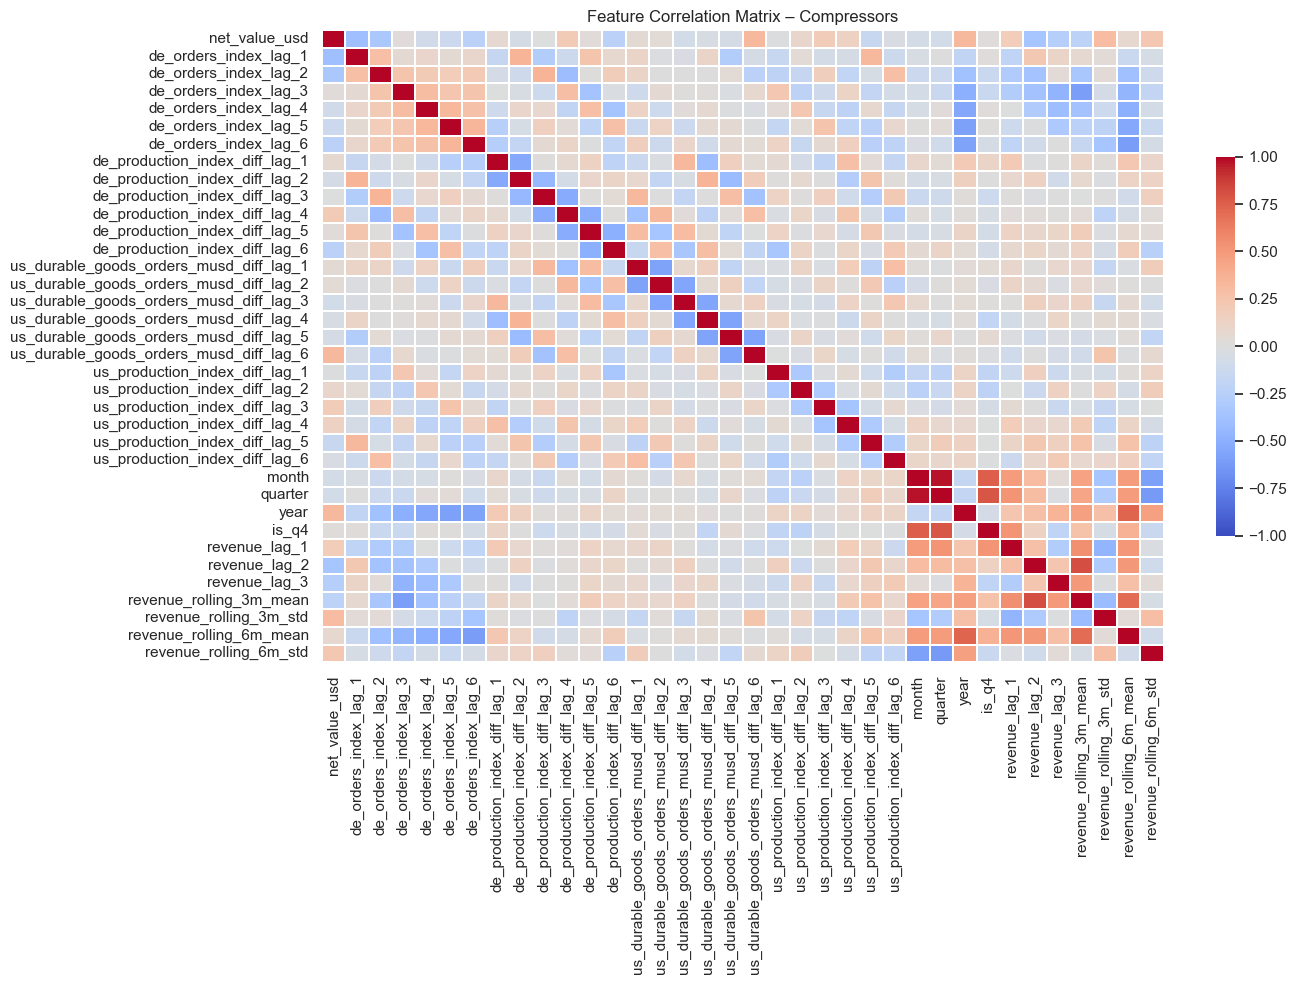

In [11]:
# Quick visual check: feature correlation heatmap (Compressors only)
comp = df_final[df_final['Product'] == 'Compressors'].drop(columns=['date', 'Product'])

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    comp.corr(),
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.6}
)
ax.set_title('Feature Correlation Matrix – Compressors', fontsize=12)
plt.tight_layout()
plt.show()

---
## 9. Save Feature Matrix

In [12]:
import os
os.makedirs(DATA_PROCESSED, exist_ok=True)

output_path = DATA_PROCESSED + 'feature_matrix.csv'
df_final.to_csv(output_path, index=False)

print(f'Saved: {output_path}')
print(f'Shape: {df_final.shape}')
df_final.head()

Saved: ../data/processed/feature_matrix.csv
Shape: (66, 38)


,date,Product,net_value_usd,de_orders_index_lag_1,de_orders_index_lag_2,de_orders_index_lag_3,de_orders_index_lag_4,de_orders_index_lag_5,de_orders_index_lag_6,de_production_index_diff_lag_1,...,quarter,year,is_q4,revenue_lag_1,revenue_lag_2,revenue_lag_3,revenue_rolling_3m_mean,revenue_rolling_3m_std,revenue_rolling_6m_mean,revenue_rolling_6m_std
0,2023-04-01,Accessories,-533.04,86.9,91.7,86.9,93.0,89.2,90.6,-2.5,...,2,2023,0,2882.58,-246.35,-1236.25,466.660000,2149.994788,1164.976667,2184.082300
1,2023-05-01,Accessories,22412.47,86.3,86.9,91.7,86.9,93.0,89.2,-0.4,...,2,2023,0,-533.04,2882.58,-246.35,701.063333,1894.679132,764.683333,2248.451684
2,2023-06-01,Accessories,1611.64,92.1,86.3,86.9,91.7,86.9,93.0,1.5,...,2,2023,0,22412.47,-533.04,2882.58,8254.003333,12379.953504,4592.770000,8991.490652
3,2023-07-01,Accessories,19051.95,92.9,92.1,86.3,86.9,91.7,86.9,-2.4,...,3,2023,0,1611.64,22412.47,-533.04,7830.356667,12673.927372,4148.508333,9075.658303
4,2023-08-01,Accessories,-2063.43,84.0,92.9,92.1,86.3,86.9,91.7,-0.5,...,3,2023,0,19051.95,1611.64,22412.47,14358.686667,11166.408228,7529.875000,10357.151888
